In [ ]:
#downloading datsase
!pip install pandas 
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install matplotlib

In [ ]:
#importing dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
#read dataset
data = pd.read_csv("iris.csv")

In [ ]:
#print basic info 
print("DATASET SHAPE")
print(data.shape)

print("\nCOLUMN NAMES")
print(data.columns.tolist())

print("\nFIRST 5 ROWS")
print(data.head())

print("\nDATASET INFORMATION")
print(data.info())

print("\nSTATISTICAL SUMMARY")
print(data.describe())

DATASET SHAPE
(150, 6)

COLUMN NAMES
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

FIRST 5 ROWS
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 n

In [ ]:
# MISSING VALUES
print("\nMISSING VALUES")
print(data.isnull().sum())


MISSING VALUES
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


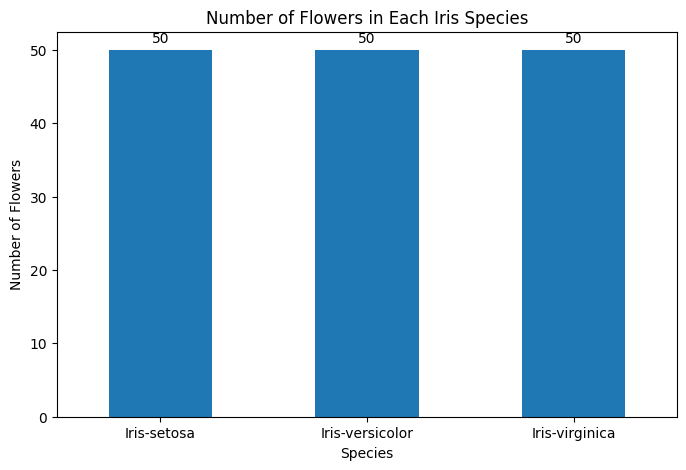

In [ ]:
# Count flowers in each species
species_count = data["Species"].value_counts()

print(species_count)

# Count flowers in each species
species_count = data["Species"].value_counts()

# Create bar graph
plt.figure(figsize=(8,5))
species_count.plot(kind="bar")

plt.title("Number of Flowers in Each Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Flowers")
plt.xticks(rotation=0)

# Display values on top of bars
for i, count in enumerate(species_count):
    plt.text(i, count + 1, str(count), ha="center")

plt.show()


AVERAGE MEASUREMENTS BY SPECIES
                    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                              
Iris-setosa       25.5          5.006         3.418          1.464   
Iris-versicolor   75.5          5.936         2.770          4.260   
Iris-virginica   125.5          6.588         2.974          5.552   

                 PetalWidthCm  
Species                        
Iris-setosa             0.244  
Iris-versicolor         1.326  
Iris-virginica          2.026  


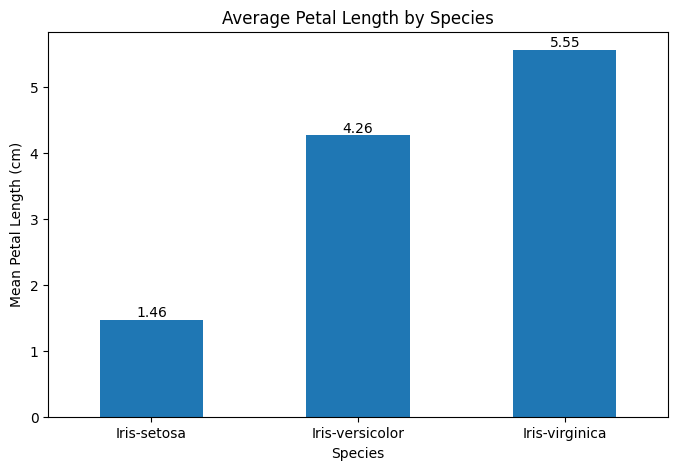

In [ ]:
# AVERAGE VALUES BY SPECIES
print("\nAVERAGE MEASUREMENTS BY SPECIES")
print(data.groupby("Species").mean())

# Calculate mean petal length for each species
mean_petal = data.groupby("Species")["PetalLengthCm"].mean()

plt.figure(figsize=(8,5))
mean_petal.plot(kind="bar")

plt.title("Average Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Mean Petal Length (cm)")
plt.xticks(rotation=0)

for i, value in enumerate(mean_petal):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.show()

                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Species                                                                  
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026


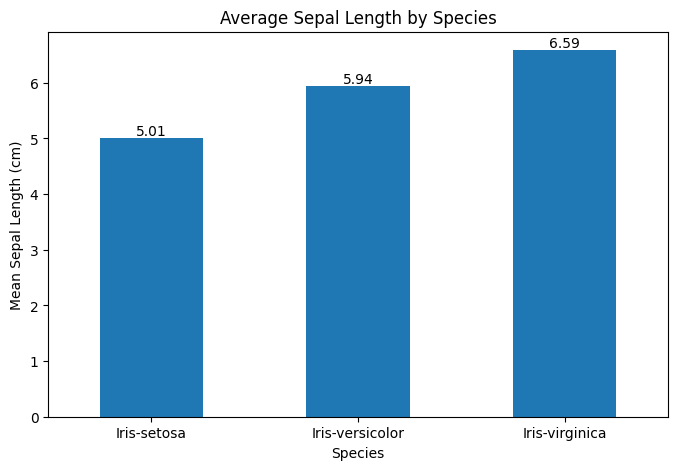

In [ ]:
#mean measurements by species
mean_measurements = data.groupby("Species")[
    ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
].mean()

print(mean_measurements)

# Calculate mean sepal length for each species
mean_sepal = data.groupby("Species")["SepalLengthCm"].mean()

plt.figure(figsize=(8,5))
mean_sepal.plot(kind="bar")

plt.title("Average Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Mean Sepal Length (cm)")
plt.xticks(rotation=0)

for i, value in enumerate(mean_sepal):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.show()

In [ ]:
# Smallest petal length
print("Smallest Petal Length:", data["PetalLengthCm"].min())

# Largest petal length
print("Largest Petal Length:", data["PetalLengthCm"].max())

# Flower with smallest petal length
print("Flower with Smallest Petal Length:")
print(data.loc[data["PetalLengthCm"].idxmin()])

# Flower with largest petal length
print("\nFlower with Largest Petal Length:")
print(data.loc[data["PetalLengthCm"].idxmax()])

#Iris-setosa has the smallest petals.
#Iris-versicolor has medium-sized petals.
#Iris-virginica has the largest petals.

Smallest Petal Length: 1.0
Largest Petal Length: 6.9
Flower with Smallest Petal Length:
Id                        23
SepalLengthCm            4.6
SepalWidthCm             3.6
PetalLengthCm            1.0
PetalWidthCm             0.2
Species          Iris-setosa
Name: 22, dtype: object

Flower with Largest Petal Length:
Id                          119
SepalLengthCm               7.7
SepalWidthCm                2.6
PetalLengthCm               6.9
PetalWidthCm                2.3
Species          Iris-virginica
Name: 118, dtype: object



CORRELATION MATRIX
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


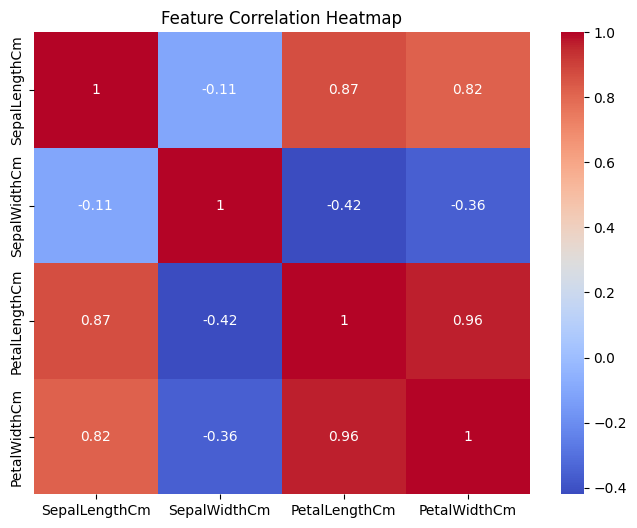

from the above data we can analyze :

 1.sepal length and petal length have a strong positive correlation (0.87) meaning as sepal length increases petal length also increases

Flowers with longer petals almost always have wider petals
 These two features grow together
 If you know the petal length, you can estimate the petal width quite accurately. 

2.SepalLengthCm ↔ PetalLengthCm = 0.87

Flowers with longer sepals tend to have longer petals.
This is a very strong positive relationship.

3.SepalLengthCm ↔ PetalWidthCm = 0.82

Another strong positive relationship.
As sepal length increases, petal width usually increases as well

4.SepalWidthCm ↔ PetalLengthCm = -0.42

Moderate negative correlation.
When sepal width increases, petal length tends to decrease somewhat.

5.SepalWidthCm ↔ PetalWidthCm = -0.36

Weak negative correlation.
When sepal width increases, petal width tends to decrease slightly.

6.PetalLengthCm ↔ PetalWidthCm = 0.96

Very strong positive correlation.
These two feat

In [ ]:
# CORRELATION MATRIX
numeric_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

correlation = data[numeric_cols].corr()

print("\nCORRELATION MATRIX")
print(correlation)

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

#| Correlation Value | Meaning                      |
#| ----------------- | ----------------------------- |
#| +1                | Perfect positive relationship |
#| +0.8              | Strong positive relationship  |
#| 0                 | No relationship               |
#| -0.8              | Strong negative relationship  |
#| -1                | Perfect negative relationship |

print("from the above data we can analyze :")
print("\n 1.sepal length and petal length have a strong positive correlation (0.87) meaning as sepal length increases petal length also increases")
print("\nFlowers with longer petals almost always have wider petals\n These two features grow together\n If you know the petal length, you can estimate the petal width quite accurately. ")
print("\n2.SepalLengthCm ↔ PetalLengthCm = 0.87")
print("\nFlowers with longer sepals tend to have longer petals.\nThis is a very strong positive relationship.")
print("\n3.SepalLengthCm ↔ PetalWidthCm = 0.82")
print("\nAnother strong positive relationship.\nAs sepal length increases, petal width usually increases as well")
print("\n4.SepalWidthCm ↔ PetalLengthCm = -0.42")
print("\nModerate negative correlation.\nWhen sepal width increases, petal length tends to decrease somewhat.")
print("\n5.SepalWidthCm ↔ PetalWidthCm = -0.36")
print("\nWeak negative correlation.\nWhen sepal width increases, petal width tends to decrease slightly.")
print("\n6.PetalLengthCm ↔ PetalWidthCm = 0.96")
print("\nVery strong positive correlation.\nThese two features are highly related.")

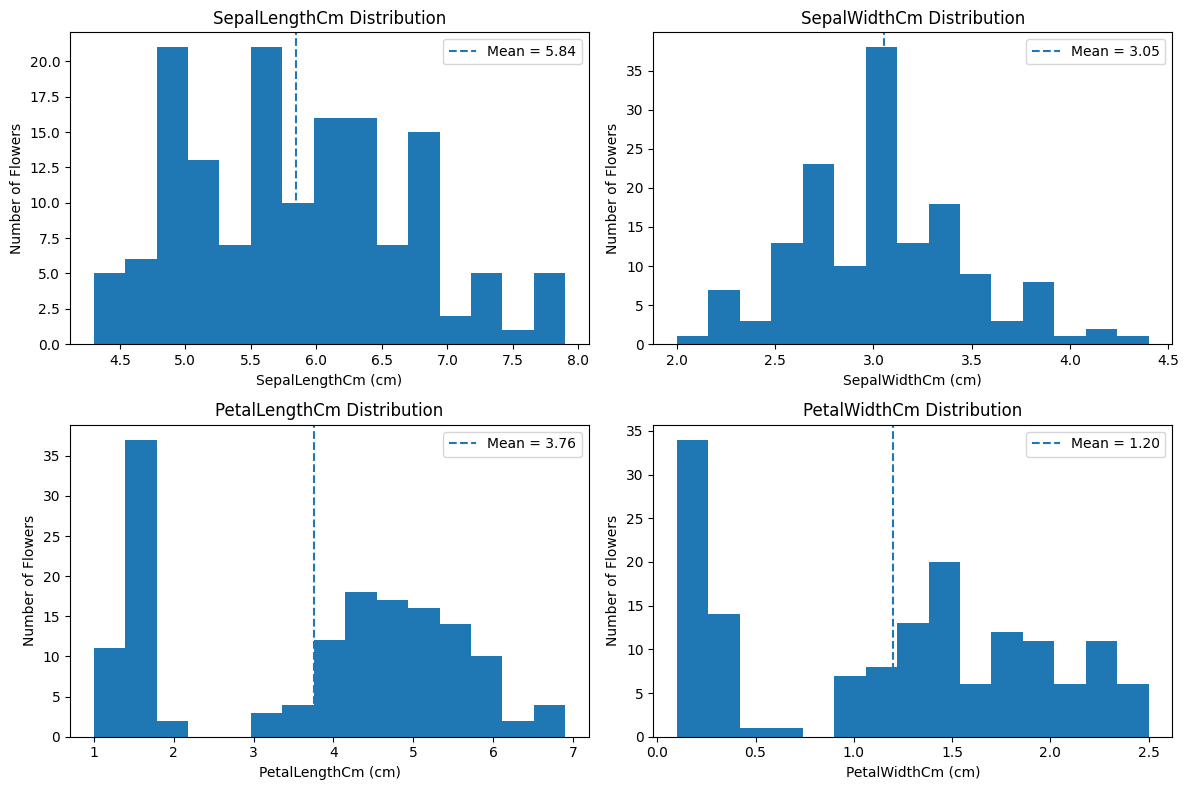

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

for ax, feature in zip(axes.flatten(), features):

    ax.hist(data[feature], bins=15)

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature + " (cm)")
    ax.set_ylabel("Number of Flowers")

    mean_val = data[feature].mean()

    ax.axvline(
        mean_val,
        linestyle="--",
        label=f"Mean = {mean_val:.2f}"
    )

    ax.legend()

plt.tight_layout()
plt.show()

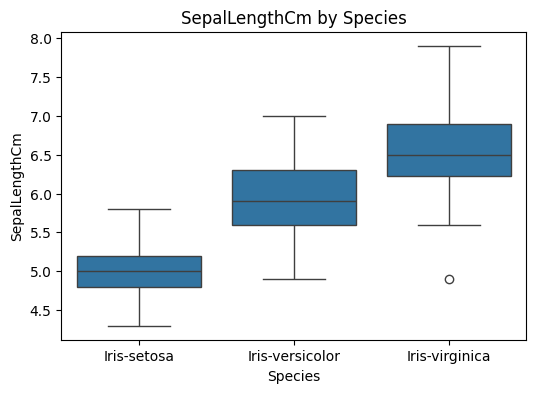

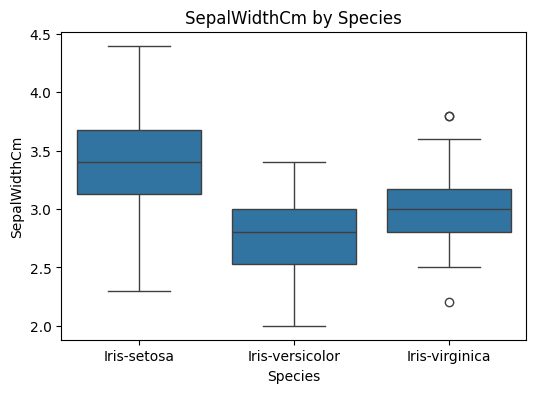

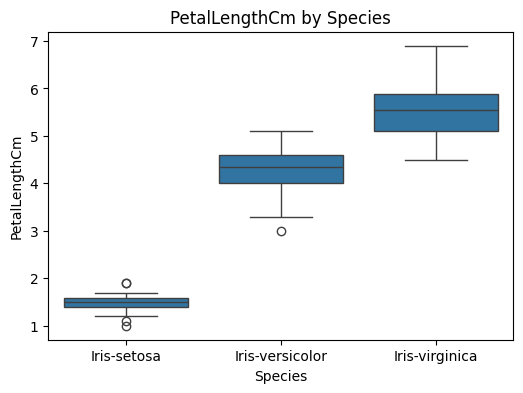

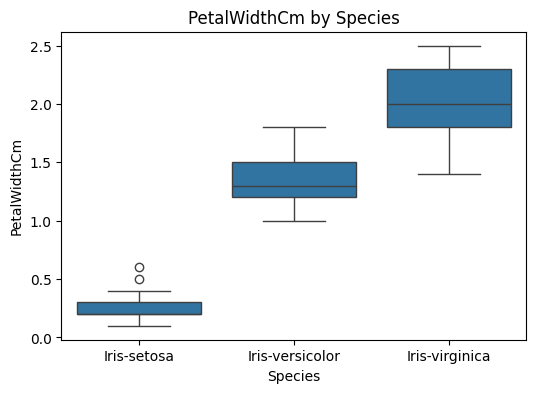

In [ ]:
# BOXPLOTS
for column in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x="Species",
        y=column,
        data=data
    )
    plt.title(f"{column} by Species")
    plt.show()


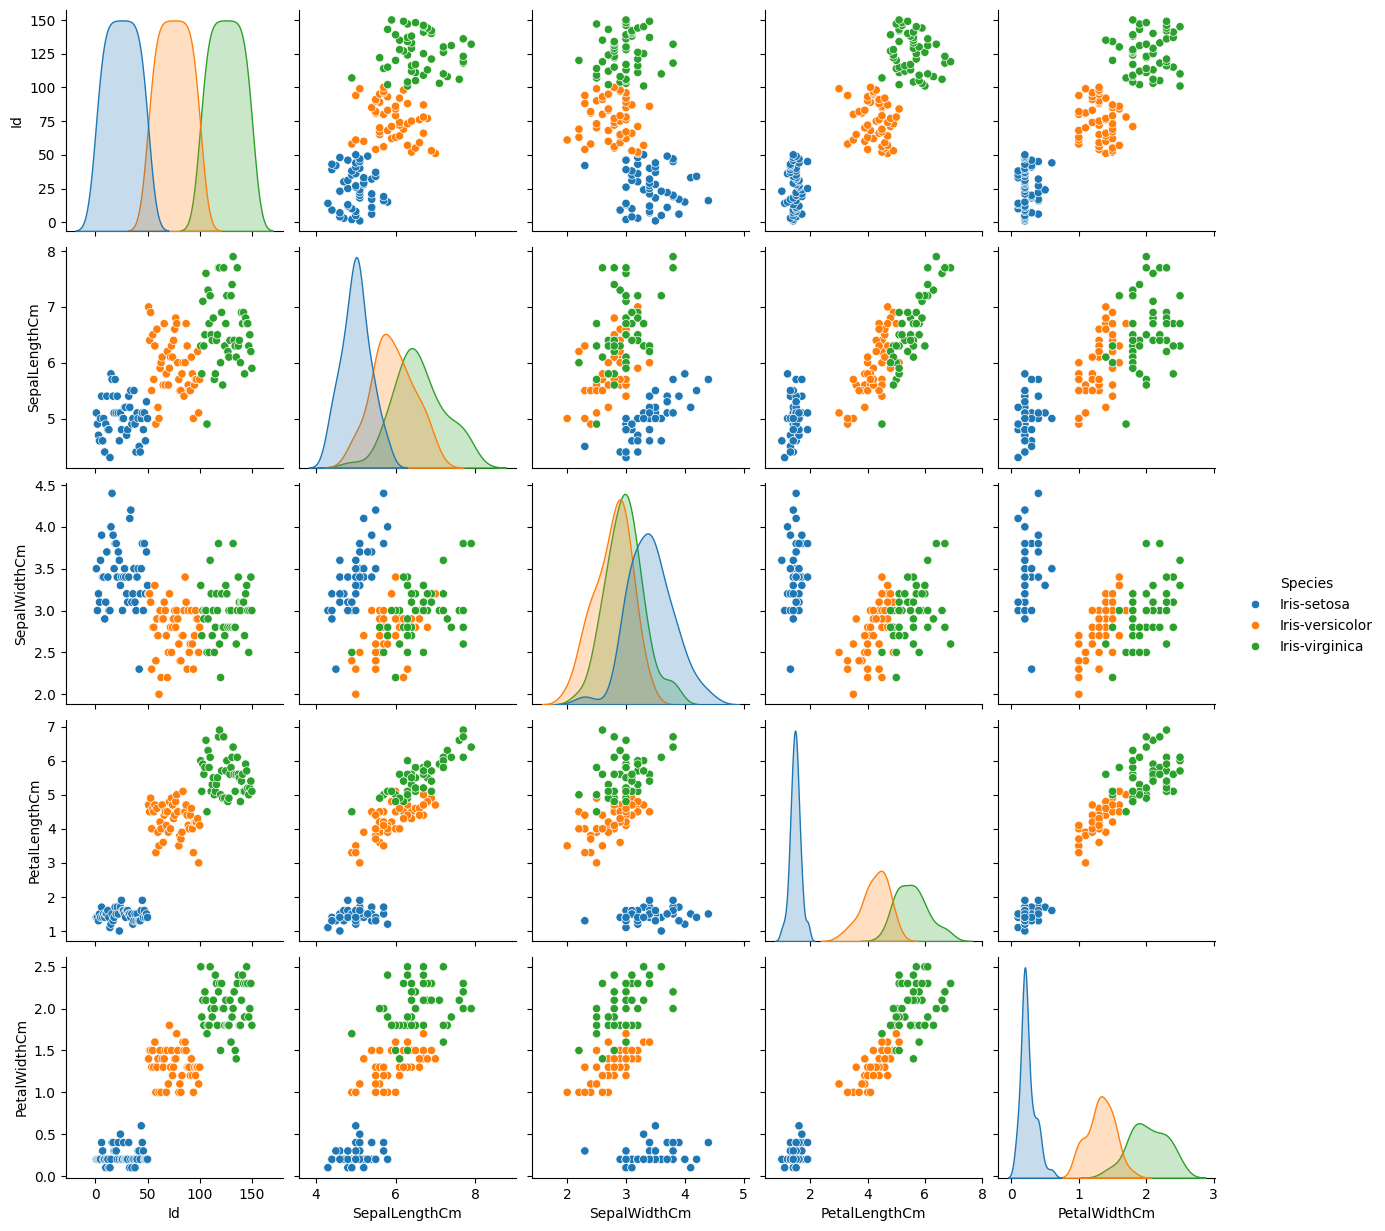

In [ ]:
# PAIRplot
sns.pairplot(
    data,
    hue="Species"
)
plt.show()

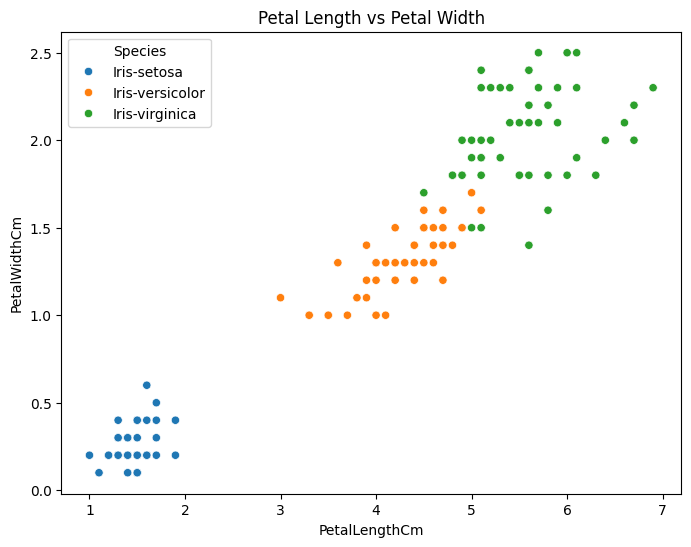

In [ ]:
# FEATURE COMPARISON
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=data
)

plt.title("Petal Length vs Petal Width")
plt.show()


In [ ]:
# MINIMUM VALUES
print("\nMINIMUM VALUES")
print(data[numeric_cols].min())

# MAXIMUM VALUES
print("\nMAXIMUM VALUES")
print(data[numeric_cols].max())

# MEAN VALUES
print("\nMEAN VALUES")
print(data[numeric_cols].mean())

# MEDIAN VALUES
print("\nMEDIAN VALUES")
print(data[numeric_cols].median())



MINIMUM VALUES
SepalLengthCm    4.3
SepalWidthCm     2.0
PetalLengthCm    1.0
PetalWidthCm     0.1
dtype: float64

MAXIMUM VALUES
SepalLengthCm    7.9
SepalWidthCm     4.4
PetalLengthCm    6.9
PetalWidthCm     2.5
dtype: float64

MEAN VALUES
SepalLengthCm    5.843333
SepalWidthCm     3.054000
PetalLengthCm    3.758667
PetalWidthCm     1.198667
dtype: float64

MEDIAN VALUES
SepalLengthCm    5.80
SepalWidthCm     3.00
PetalLengthCm    4.35
PetalWidthCm     1.30
dtype: float64


In [ ]:
# STANDARD DEVIATION
print("\nSTANDARD DEVIATION")
print(data[numeric_cols].std())



STANDARD DEVIATION
SepalLengthCm    0.828066
SepalWidthCm     0.433594
PetalLengthCm    1.764420
PetalWidthCm     0.763161
dtype: float64


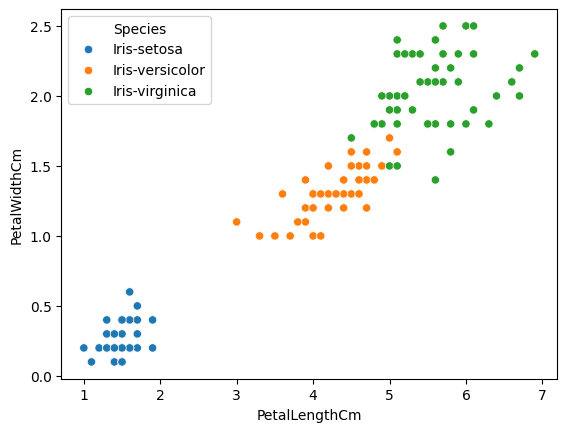

In [ ]:
sns.scatterplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    data=data
)

plt.show()

In [ ]:
X = data[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = data["Species"]

model = RandomForestClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.09920797 0.02554891 0.46728985 0.40795327]


In [ ]:
##The dataset is perfectly balanced (50 flowers per species).
##Petal features are the strongest indicators of species.
##Setosa is clearly distinguishable from the other species.
##Virginica has the largest petals and overall dimensions.
##Petal length and petal width are highly correlated.
##Sepal width is the least informative feature.
##The dataset is highly suitable for classification, with models often achieving 95–100% accuracy.

In [1]:
py --version

NameError: name 'py' is not defined